In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import seaborn as sns

np.random.seed(42)
tf.random.set_seed(42)

NUM_CLASSES = 10
INPUT_SHAPE = (32, 32, 3) 

BATCH_SIZE = 64
EPOCHS = 15 
VALIDATION_SPLIT = 0.2

PATCH_SIZE = 4
EMBED_DIM = 192
DEPTH = 6
NUM_HEADS = 6
MLP_DIM = 384
DROPOUT_RATE = 0.1

IMAGE_SIZE = INPUT_SHAPE[0]
NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [ ]:
def load_and_preprocess_data():
    """Loads CIFAR-10, normalizes pixel values, and one-hot encodes labels."""
    print("Loading and Pre-processing Data...")

    (x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

    x_train = x_train.astype("float32") / 255.0
    x_test = x_test.astype("float32") / 255.0

    y_train = keras.utils.to_categorical(y_train, NUM_CLASSES)
    y_test = keras.utils.to_categorical(y_test, NUM_CLASSES)

    print(f"x_train shape: {x_train.shape}, y_train shape: {y_train.shape}")
    print(f"x_test shape: {x_test.shape}, y_test shape: {y_test.shape}")

    return x_train, y_train, x_test, y_test

x_train, y_train_one_hot, x_test, y_test_one_hot = load_and_preprocess_data()

y_test_labels = np.argmax(y_test_one_hot, axis=1)

Loading and Pre-processing Data...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
x_train shape: (50000, 32, 32, 3), y_train shape: (50000, 10)
x_test shape: (10000, 32, 32, 3), y_test shape: (10000, 10)


In [ ]:
def mlp(x, hidden_units, dropout_rate):
    """Simple Multi-Layer Perceptron block."""
    for units in hidden_units:
        x = layers.Dense(units, activation=tf.nn.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

class Patches(layers.Layer):
    """Splits images into non-overlapping patches."""
    def __init__(self, patch_size, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]

        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )

        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

    def get_config(self):
        config = super().get_config()
        config.update({"patch_size": self.patch_size})
        return config

class PatchEncoder(layers.Layer):
    """Linearly projects patches and adds learnable positional embeddings."""
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)

        self.position_embedding = layers.Embedding(
            input_dim=num_patches + 1, output_dim=projection_dim
        )

        self.class_token = tf.Variable(tf.zeros((1, 1, projection_dim)))

    def call(self, patch):

        batch_size = tf.shape(patch)[0]
        cls_token_broadcast = tf.tile(self.class_token, [batch_size, 1, 1])

        encoded_patches = self.projection(patch)

        encoded_patches = tf.concat([cls_token_broadcast, encoded_patches], axis=1)

        positions = tf.range(start=0, limit=self.num_patches + 1, delta=1)

        encoded_patches += self.position_embedding(positions)
        return encoded_patches

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_patches": self.num_patches,
            "projection_dim": self.projection.units,
        })
        return config

def create_vit_classifier():
    """Builds the complete Vision Transformer model."""
    inputs = keras.Input(shape=INPUT_SHAPE)

    patches = Patches(PATCH_SIZE)(inputs)

    encoded_patches = PatchEncoder(NUM_PATCHES, EMBED_DIM)(patches)

    for _ in range(DEPTH):

        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)

        attention_output = layers.MultiHeadAttention(
            num_heads=NUM_HEADS, key_dim=EMBED_DIM // NUM_HEADS, dropout=DROPOUT_RATE
        )(x1, x1)

        x2 = layers.Add()([attention_output, encoded_patches])

        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)

        x3 = mlp(x3, hidden_units=[MLP_DIM, EMBED_DIM], dropout_rate=DROPOUT_RATE)

        encoded_patches = layers.Add()([x3, x2])

    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = representation[:, 0, :] 

    logits = layers.Dense(NUM_CLASSES, activation="softmax")(representation)

    model = keras.Model(inputs=inputs, outputs=logits)
    return model

vit_model = create_vit_classifier()
vit_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches (Patches)   │ (None, None, 48)  │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder       │ (None, 65, 192)   │     21,888 │ patches[0][0]     │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 65, 192)   │        384 │ patch_encoder[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 65, 192)   │    148,224 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 65, 192)   │          0 │ multi_head_atten… │
│                     │                   │            │ patch_encoder[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 65, 192)   │        384 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 65, 384)   │     74,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 65, 384)   │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 65, 192)   │     73,920 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 65, 192)   │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 65, 192)   │          0 │ dropout_2[0][0],  │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 65, 192)   │        384 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 65, 192)   │    148,224 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 65, 192)   │          0 │ multi_head_atten… │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 65, 192)   │        384 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 65, 384)   │     74,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 65, 384)   │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 65, 192)   │     73,920 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,806,346 (6.89 MB)

 Trainable params: 1,806,346 (6.89 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = keras.optimizers.Adam(learning_rate=1e-4) 

loss_fn = keras.losses.CategoricalCrossentropy()

metrics_list = ['accuracy']

vit_model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=metrics_list
)

In [ ]:
print("\n--- Starting Model Training ---")

history = vit_model.fit(
    x_train,
    y_train_one_hot,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=VALIDATION_SPLIT, 
    verbose=2 
)

print("--- Training Complete ---")


--- Starting Model Training ---
Epoch 1/15
625/625 - 61s - 98ms/step - accuracy: 0.2796 - loss: 1.9223 - val_accuracy: 0.4076 - val_loss: 1.6185
Epoch 2/15
625/625 - 23s - 37ms/step - accuracy: 0.4243 - loss: 1.5503 - val_accuracy: 0.4821 - val_loss: 1.4390
Epoch 3/15
625/625 - 24s - 38ms/step - accuracy: 0.5046 - loss: 1.3493 - val_accuracy: 0.5258 - val_loss: 1.3086
Epoch 4/15
625/625 - 24s - 38ms/step - accuracy: 0.5494 - loss: 1.2342 - val_accuracy: 0.5538 - val_loss: 1.2460
Epoch 5/15
625/625 - 25s - 39ms/step - accuracy: 0.5835 - loss: 1.1495 - val_accuracy: 0.5784 - val_loss: 1.1926
Epoch 6/15
625/625 - 24s - 39ms/step - accuracy: 0.6119 - loss: 1.0799 - val_accuracy: 0.5989 - val_loss: 1.1505
Epoch 7/15
625/625 - 24s - 39ms/step - accuracy: 0.6311 - loss: 1.0181 - val_accuracy: 0.6122 - val_loss: 1.1129
Epoch 8/15
625/625 - 24s - 39ms/step - accuracy: 0.6497 - loss: 0.9693 - val_accuracy: 0.6207 - val_loss: 1.0869
Epoch 9/15
625/625 - 24s - 39ms/step - accuracy: 0.6715 - loss:


--- Evaluating on Test Data ---
157/157 - 3s - 19ms/step - accuracy: 0.6437 - loss: 1.1241
Test Loss: 1.1241
Test Accuracy: 0.6437


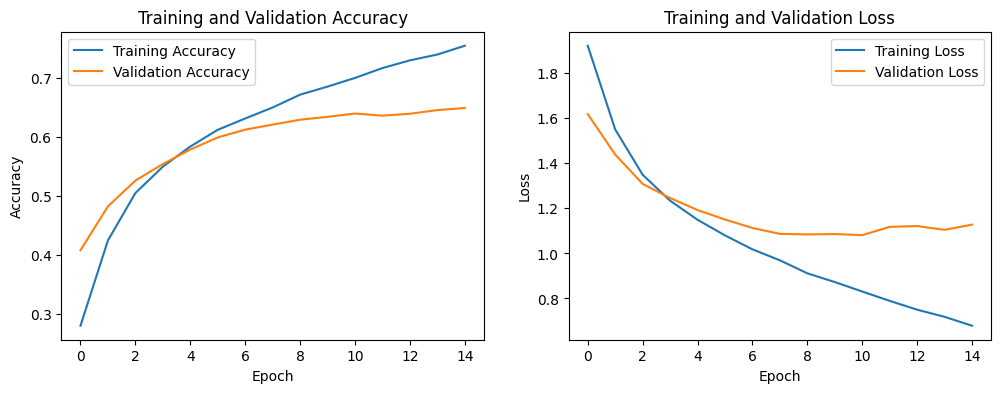

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step


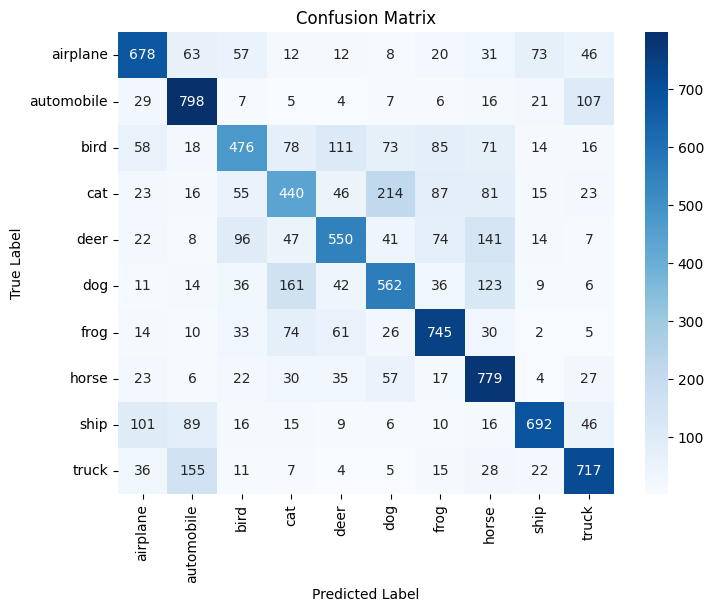


--- Classification Report ---
              precision    recall  f1-score   support

    airplane     0.6814    0.6780    0.6797      1000
  automobile     0.6780    0.7980    0.7331      1000
        bird     0.5884    0.4760    0.5263      1000
         cat     0.5063    0.4400    0.4708      1000
        deer     0.6293    0.5500    0.5870      1000
         dog     0.5626    0.5620    0.5623      1000
        frog     0.6804    0.7450    0.7112      1000
       horse     0.5919    0.7790    0.6727      1000
        ship     0.7991    0.6920    0.7417      1000
       truck     0.7170    0.7170    0.7170      1000

    accuracy                         0.6437     10000
   macro avg     0.6434    0.6437    0.6402     10000
weighted avg     0.6434    0.6437    0.6402     10000

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


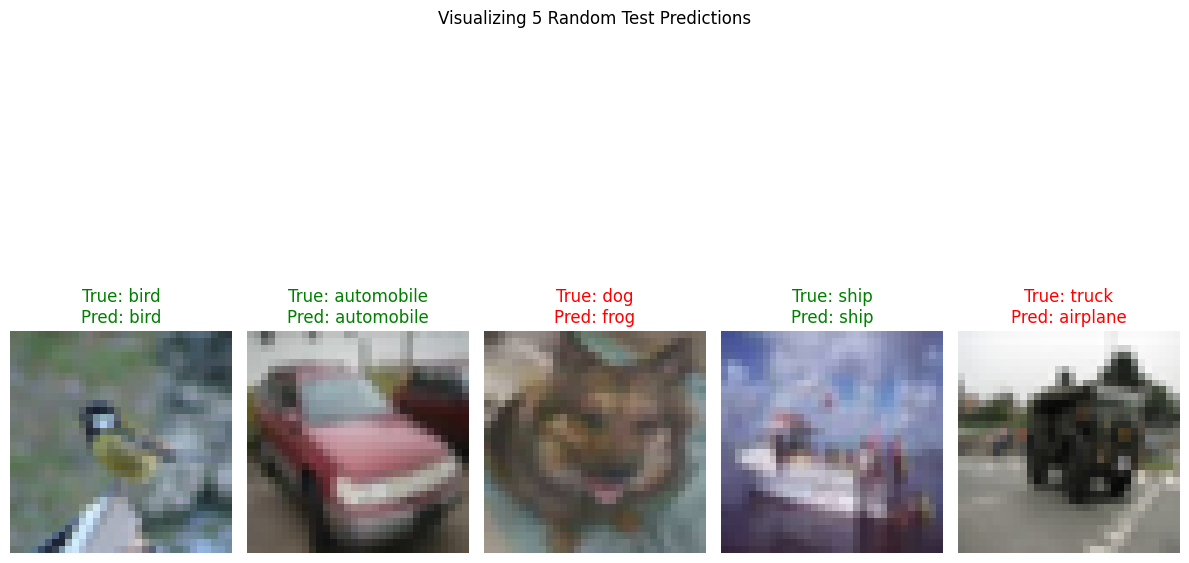

In [ ]:
print("\n--- Evaluating on Test Data ---")
loss, accuracy = vit_model.evaluate(x_test, y_test_one_hot, batch_size=BATCH_SIZE, verbose=2)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

def plot_history(history):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

plot_history(history)

y_pred_one_hot = vit_model.predict(x_test)
y_pred_labels = np.argmax(y_pred_one_hot, axis=1)

cm = confusion_matrix(y_test_labels, y_pred_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\n--- Classification Report ---")
report = classification_report(y_test_labels, y_pred_labels, target_names=CLASS_NAMES, digits=4)
print(report)

def visualize_predictions(model, x_test, y_test_labels, class_names, num_images=5):
    plt.figure(figsize=(12, 8))

    indices = np.random.choice(x_test.shape[0], num_images, replace=False)

    sample_images = x_test[indices]
    sample_preds = model.predict(sample_images)
    sample_pred_labels = np.argmax(sample_preds, axis=1)

    for i, idx in enumerate(indices):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(sample_images[i])

        true_label = class_names[y_test_labels[idx]]
        pred_label = class_names[sample_pred_labels[i]]

        title_color = 'green' if true_label == pred_label else 'red'
        plt.title(f"True: {true_label}\nPred: {pred_label}", color=title_color)
        plt.axis('off')

    plt.suptitle(f"Visualizing {num_images} Random Test Predictions", y=1.02)
    plt.tight_layout()
    plt.show()

visualize_predictions(vit_model, x_test, y_test_labels, CLASS_NAMES)